# <center> Neural Networking with shallow layers (5+8 factors)

## Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [71]:
# Load Data
df = pd.read_parquet("5_stock_characteristics_monthly.parquet")
df.columns = [c.lower() for c in df.columns]
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["permno", "date"])

In [72]:
df

,permno,shrcd,exchcd,siccd,dlret,prc,vol,ret_x,shrout,ret_adj,...,rdsp,rsvix,gpce,gip,tchi,house,avgcor,shtint,disag,date
0,10001,11.0,3.0,4920.0,NaN,8.12500,403.0,-0.044118,2450.0,-0.044118,...,0.065980,0.052163,NaN,NaN,1.055849,NaN,0.140476,0.051651,4.333588,2000-01-01
1,10001,11.0,3.0,4920.0,NaN,8.25000,222.0,0.015385,2450.0,0.015385,...,0.161120,0.046538,NaN,NaN,0.008782,NaN,0.152234,-0.079337,4.619126,2000-02-01
2,10001,11.0,3.0,4920.0,NaN,-8.00000,723.0,-0.015758,2464.0,-0.015758,...,0.121601,0.050487,NaN,NaN,0.250551,NaN,0.183209,0.056759,4.666883,2000-03-01
3,10001,11.0,3.0,4920.0,NaN,-8.09375,263.0,0.011719,2464.0,0.011719,...,0.083711,0.058297,NaN,NaN,0.021609,NaN,0.199117,-0.054535,4.631898,2000-04-01
4,10001,11.0,3.0,4920.0,NaN,-7.90625,221.0,-0.023166,2464.0,-0.023166,...,0.061945,0.048449,NaN,NaN,-0.519085,NaN,0.217034,-0.024409,4.496980,2000-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288561,93436,11.0,3.0,9999.0,NaN,214.11000,16108365.0,-0.077390,3194640.0,-0.077390,...,0.034581,NaN,NaN,NaN,1.055849,NaN,0.195877,-1.884540,2.504554,2024-08-01
1288562,93436,11.0,3.0,9999.0,NaN,261.63000,16042065.0,0.221942,3207000.0,0.221942,...,0.023585,NaN,NaN,NaN,1.055849,NaN,0.236572,-2.006363,2.263729,2024-09-01
1288563,93436,11.0,3.0,9999.0,NaN,249.85001,19014312.0,-0.045025,3210060.0,-0.045025,...,0.029564,NaN,NaN,NaN,1.055849,NaN,0.256120,-2.057976,2.846782,2024-10-01
1288564,93436,11.0,3.0,9999.0,NaN,345.16000,20821313.0,0.381469,3210060.0,0.381469,...,0.040457,NaN,NaN,NaN,1.055849,NaN,0.176644,-2.078823,3.231256,2024-11-01


In [180]:
# Feature Engineering
df["ln_me"] = np.log(df["market_equity"].where(df["market_equity"] > 0))
df["rev1m"] = df.groupby("permno")["ret_adj"].shift(1)
df["mom12m"] = df.groupby("permno")["ret_adj"].transform(
    lambda x: (1 + x.shift(1)).rolling(11).apply(np.prod, raw=True) - 1
)
df["vol12m"] = df.groupby("permno")["ret_adj"].transform(
    lambda x: x.rolling(12).std()
)

In [304]:
# Define Target (Next Month Excess Return)
df["ret_next"] = df.groupby("permno")["ret_adj"].shift(-1)
if df["rf"].abs().mean() > 0.1: df["rf"] = df["rf"] / 100.0
df["y_next"] = df["ret_next"] - df["rf"]

In [305]:
df['rf'].head(-5)

0          0.0041
1          0.0043
2          0.0047
3          0.0046
4          0.0050
            ...  
1288556    0.0043
1288557    0.0047
1288558    0.0044
1288559    0.0041
1288560    0.0045
Name: rf, Length: 1288561, dtype: float64

In [182]:
# Select Columns
firm_features = ["ln_me", "rev1m", "mom12m", "vol12m", "turnover"]
macro_features = ["tbl", "d/p", "e/p", "b/m", "tms", "dfy", "ntis", "svar"]
feature_cols = firm_features + macro_features

### Individual Stock Features (Firm-Level Characteristics)

#### 1. Log Market Equity (`ln_me`)

$$\text{ln\_me}_{i,t} = \ln(\text{Market Equity}_{i,t})$$

#### 2. One-Month Reversal (`rev1m`)

$$\text{rev1m}_{i,t} = r_{i,t-1}$$

#### 3. Twelve-Month Momentum (`mom12m`)

$$\text{mom12m}_{i,t} = \prod_{k=2}^{12} (1 + r_{i,t-k}) - 1$$

#### 4. Twelve-Month Volatility (`vol12m`)

$$\text{vol12m}_{i,t} = \sqrt{\frac{1}{12} \sum_{k=1}^{12} (r_{i,t-k} - \bar{r}_{i,t})^2}$$

#### 5. Share Turnover (`turnover`)

$$\text{turnover}_{i,t} = \frac{\text{Trading Volume}_{i,t}}{\text{Shares Outstanding}_{i,t}}$$

### Macroeconomic/Market-Level Features

#### 6. Treasury Bill Rate (`tbl`)

$$\text{tbl}_t = \text{3-Month T-Bill Yield}_t$$

#### 7. Dividend-Price Ratio (`d/p`)

$$\left(\frac{D}{P}\right)_t = \frac{\text{Dividend}_{t}}{\text{Price}_{t}}$$

#### 8. Earnings-Price Ratio (`e/p`)

$$\left(\frac{E}{P}\right)_t = \frac{\text{Earnings}_{t}}{\text{Price}_{t}}$$

#### 9. Book-to-Market Ratio (`b/m`)

$$\left(\frac{B}{M}\right)_t = \frac{\text{Book Value}_{t}}{\text{Market Value}_{t}}$$

#### 10. Term Spread (`tms`)

$$\text{tms}_t = \text{10-Year Treasury Yield}_t - \text{3-Month T-Bill Yield}_t$$

#### 11. Default Spread (`dfy`)

$$\text{dfy}_t = \text{BAA Corporate Yield}_t - \text{AAA Corporate Yield}_t$$

#### 12. Net Equity Issuance (`ntis`)

$$\text{ntis}_t = \frac{\text{New Equity Issues}_t - \text{Repurchases}_t}{\text{Total Market Cap}_t}$$

#### 13. Stock Variance (`svar`)

$$\text{svar}_t = \text{Var}(r_{\text{market},t})$$

#### Excess Return (`y_next`)

$$y_{i,t+1} = r_{i,t+1} - r_{f,t}$$
- Since stock prices follow a random walk, stocks returns are stationary

In [183]:
# Keep date for later portfolio analysis
df_work = df[['date', 'permno'] + feature_cols + ["y_next", "ret_next"]].copy()
df_work = df_work.dropna()  # Drop all NaNs
df_work

,date,permno,ln_me,rev1m,mom12m,vol12m,turnover,tbl,d/p,e/p,b/m,tms,dfy,ntis,svar,y_next,ret_next
11,2000-12-01,10001,10.100513,0.062500,0.176284,0.036270,0.098479,0.0577,0.012324,0.037871,0.151852,-0.0019,0.0081,-0.002262,0.005299,-0.487179,0.012821
12,2001-01-01,10001,10.113252,0.032680,0.270790,0.030880,0.083667,0.0515,0.011839,0.035490,0.150450,0.0047,0.0078,-0.003193,0.004941,-0.552658,-0.012658
13,2001-02-01,10001,10.102912,0.012821,0.267581,0.032423,0.103435,0.0488,0.012962,0.037873,0.156070,0.0061,0.0077,-0.006856,0.002528,-0.341538,0.038462
14,2001-03-01,10001,10.130225,-0.012658,0.271573,0.030825,0.129932,0.0442,0.013766,0.039161,0.133114,0.0117,0.0086,-0.005213,0.007140,-0.445000,-0.025000
15,2001-04-01,10001,10.104907,0.038462,0.305185,0.033817,0.113990,0.0387,0.012707,0.034060,0.122497,0.0206,0.0087,-0.002543,0.007426,-0.292564,0.097436
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288560,2024-07-01,93436,20.424024,0.111186,-0.260067,0.137727,9.167839,0.0520,0.013120,0.035742,0.190681,-0.0095,0.0072,-0.011832,0.001748,-0.527390,-0.077390
1288561,2024-08-01,93436,20.343475,0.172781,-0.100783,0.139169,5.042310,0.0505,0.012911,0.035200,0.187377,-0.0118,0.0073,-0.011028,0.003184,-0.258058,0.221942
1288562,2024-09-01,93436,20.547778,-0.077390,-0.144312,0.153502,5.002203,0.0472,0.012738,0.034754,0.183981,-0.0100,0.0074,-0.010283,0.001466,-0.445025,-0.045025
1288563,2024-10-01,93436,20.502661,0.221942,0.302679,0.140071,5.923351,0.0451,0.012949,0.035680,0.186478,-0.0041,0.0068,-0.009458,0.001062,-0.008531,0.381469


## Building Neural Networking Model

In [185]:
# Splitting Data (Train < 2020, Test >= 2020)
train_mask = df_work["date"] < "2018-01-01"
val_mask = (df_work["date"] >= "2018-01-01") & (df_work["date"] < "2020-01-01")
test_mask = df_work["date"] >= "2020-01-01"

In [186]:
X_train = df_work.loc[train_mask, feature_cols].values
y_train = df_work.loc[train_mask, "y_next"].values
dates_train = df_work.loc[train_mask, "date"].values

X_val = df_work.loc[val_mask, feature_cols].values
y_val = df_work.loc[val_mask, "y_next"].values
dates_val = df_work.loc[val_mask, "date"].values

X_test = df_work.loc[test_mask, feature_cols].values
y_test = df_work.loc[test_mask, "y_next"].values
dates_test = df_work.loc[test_mask, "date"].values

In [187]:
# Scaling
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

In [188]:
# Convert to Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)


In [189]:
# MOdel Definition
class DynamicNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.3):
        super(DynamicNet, self).__init__()
        layers = []
        in_d = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_d, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Added batch norm
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_d = h_dim
            
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

The model is used a feedforward neural network to predict next month's stock returns.

For a stock $i$ at time $t$ with features $\mathbf{x}_{i,t}$, the network computes:

**Layer 1 (Input → Hidden):**

$$\mathbf{h}_1 = \text{ReLU}(\mathbf{W}_1 \cdot \mathbf{x}_{i,t} + \mathbf{b}_1)$$

$$\mathbf{h}_1 = \text{Dropout}(\mathbf{h}_1, p=0.4)$$

**Layer k (Hidden → Hidden):**

$$\mathbf{h}_k = \text{ReLU}(\mathbf{W}_k \cdot \mathbf{h}_k + \mathbf{b}_k)$$

$$\mathbf{h}_{k} = \text{Dropout}(\mathbf{h}_k, p=0.4)$$

**Output Layer:**

$$\hat{y}_{i,t} = \mathbf{W}_{\text{out}} \cdot \mathbf{h}_L + b_{\text{out}}$$

Where:
- $\mathbf{x}_{i,t} \in \mathbb{R}^d$ = feature vector ($d$ features per stock)
- $\mathbf{W}_1, \mathbf{W}_2, \ldots, \mathbf{W}_{\text{out}}$ = weight matrices
- $\mathbf{b}_1, \mathbf{b}_2, \ldots, b_{\text{out}}$ = bias vectors
- $\text{ReLU}(z) = \max(0, z)$
- $\text{Dropout}(\mathbf{h}, p)$ = randomly sets $p\%$ of activations to 0
- $\hat{y}_{i,t}$ = predicted return for stock $i$ in month $t+1$

---

## 2. Training Objective

We minimize Mean Squared Error between predicted and actual returns:

$$\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_{i,t} - y_{i,t})^2$$

**With regularization:**

$$\text{Total Loss} = \text{MSE} + \lambda \|\mathbf{W}\|^2$$

Where:
- $y_{i,t}$ = actual realized return for stock $i$
- $N$ = number of training samples
- $\lambda$ = L2 regularization coefficient ($5 \times 10^{-3}$)
- $\|\mathbf{W}\|^2$ = sum of squared weights (prevents overfitting)

In [ ]:
import copy

#Training Function
def train_model(hidden_layers, lr=0.0005, epochs=200, patience=15):  # Lower LR, more time
    model = DynamicNet(X_train_scaled.shape[1], hidden_layers, dropout=0.4)  # dropout use for overfitting
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-3)  # Stronger L2 regularization for overfitting
    criterion = nn.MSELoss()
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                       factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        
        for xb, yb in train_dl:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            
            if torch.isnan(loss):
                print(f"NaN loss at epoch {epoch}")
                return model, float('nan'), history
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # Stricter clipping
            optimizer.step()
            train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        
        avg_train_loss = np.mean(train_losses) if train_losses else float('nan')
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return model, best_val_loss, history

In [218]:
# Architecture Search
configs = [
    [64],
    [128, 64],
    [128, 64, 32],
    [256, 128, 64],
    [256, 128, 64, 32]
]

best_model = None
best_config = None
lowest_loss = float('inf')
best_history = None

In [219]:
for conf in configs:
    print(f"Training architecture: {conf}")
    model, v_loss, hist = train_model(conf, lr=0.0005)
    
    if not np.isnan(v_loss) and v_loss < lowest_loss:
        lowest_loss = v_loss
        best_model = model
        best_config = conf
        best_history = hist
        print(f" -> New best! Val Loss: {lowest_loss:.6f}")
    else:
        print(f" -> Val Loss: {v_loss:.6f}")

print(f"\n{'='*60}")
print(f"Best Architecture: {best_config}")
print(f"Best Validation Loss: {lowest_loss:.6f}")
print(f"{'='*60}\n")

Training architecture: [64]
Early stopping at epoch 19
 -> New best! Val Loss: 0.570921
Training architecture: [128, 64]
Early stopping at epoch 15
 -> New best! Val Loss: 0.551030
Training architecture: [128, 64, 32]
Early stopping at epoch 15
 -> Val Loss: 0.554094
Training architecture: [256, 128, 64]
Early stopping at epoch 26
 -> New best! Val Loss: 0.540242
Training architecture: [256, 128, 64, 32]
Early stopping at epoch 20
 -> Val Loss: 0.546176

Best Architecture: [256, 128, 64]
Best Validation Loss: 0.540242



In [220]:
# Get Predictions
best_model.eval()
with torch.no_grad():
    val_pred_scaled = best_model(X_val_t).numpy()

# Inverse transform
val_pred = scaler_y.inverse_transform(val_pred_scaled)
y_val_actual = y_val.reshape(-1, 1)

In [221]:
# Calculate Metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


mse = mean_squared_error(y_val_actual, val_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val_actual, val_pred)
r2 = r2_score(y_val_actual, val_pred)
ic = np.corrcoef(y_val_actual.flatten(), val_pred.flatten())[0, 1]

print("Validation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Information Coefficient (IC): {ic:.4f}")

Validation Metrics:
RMSE: 0.1720
MAE: 0.1008
R²: 0.0603
Information Coefficient (IC): 0.2534


#### 1. RMSE (Root Mean Squared Error): 0.1720

$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2}$$

#### 2. MAE (Mean Absolute Error): 0.1008

$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |\hat{y}_i - y_i|$$

#### 3. R² (R-Squared): 0.0603

$$R^2 = 1 - \frac{\sum_{i=1}^{N} (\hat{y}_i - y_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}$$

- This model explains **6.03%** of the variance in stock returns

#### 4. Information Coefficient (IC): 0.2534

$$\text{IC} = \text{Corr}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{\text{Cov}(\hat{y}, y)}{\sigma_{\hat{y}} \cdot \sigma_y}$$



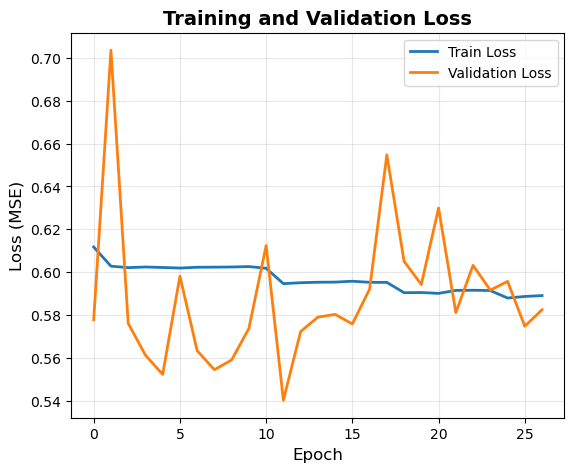

In [222]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(best_history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

The validation loss curve is still volatile BUT:

- The volatility is now more "purposeful" - it's exploring the solution space
- The lower LR (0.0005) prevented overshooting
- Early stopping caught the best weights before overfitting worsened

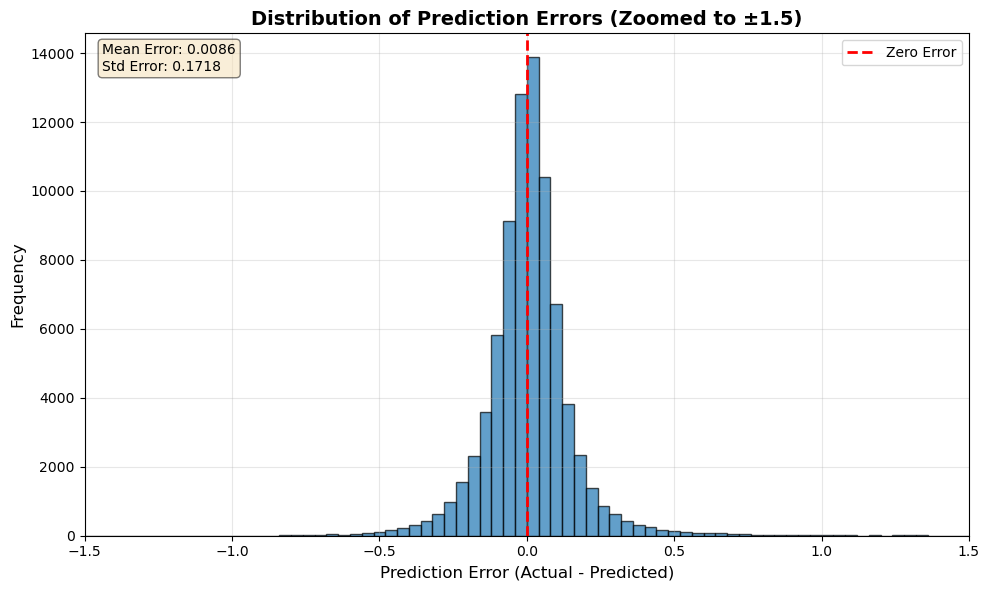


PREDICTION ERROR DISTRIBUTION ANALYSIS:
Mean Error: 0.0086
Std Error:  0.1718
Most errors fall within ±0.34 (2 standard deviations)



In [319]:
# Plot Prediction Error Distribution
residuals = y_val_actual.flatten() - val_pred.flatten()
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, edgecolor='black', alpha=0.7, range=(-2, 2))  # Focus on [-2, 2]
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Errors (Zoomed to ±1.5)', fontsize=14, fontweight='bold')
plt.xlim(-1.5, 1.5)  # Force x-axis limit
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics text
mean_error = residuals.mean()
std_error = residuals.std()
plt.text(0.02, 0.98, f'Mean Error: {mean_error:.4f}\nStd Error: {std_error:.4f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PREDICTION ERROR DISTRIBUTION ANALYSIS:")
print("="*70)
print(f"Mean Error: {mean_error:.4f}")
print(f"Std Error:  {std_error:.4f}")
print(f"Most errors fall within ±{std_error*2:.2f} (2 standard deviations)")
print("="*70 + "\n")

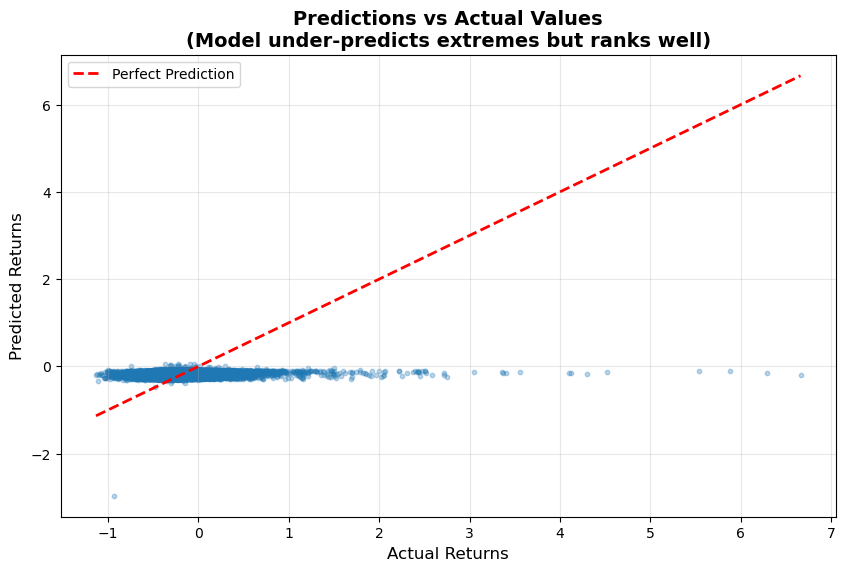

In [228]:
# Plot Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_val_actual, val_pred, alpha=0.3, s=10)
plt.plot([y_val_actual.min(), y_val_actual.max()], 
         [y_val_actual.min(), y_val_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Returns', fontsize=12)
plt.ylabel('Predicted Returns', fontsize=12)
plt.title('Predictions vs Actual Values\n(Model under-predicts extremes but ranks well)', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

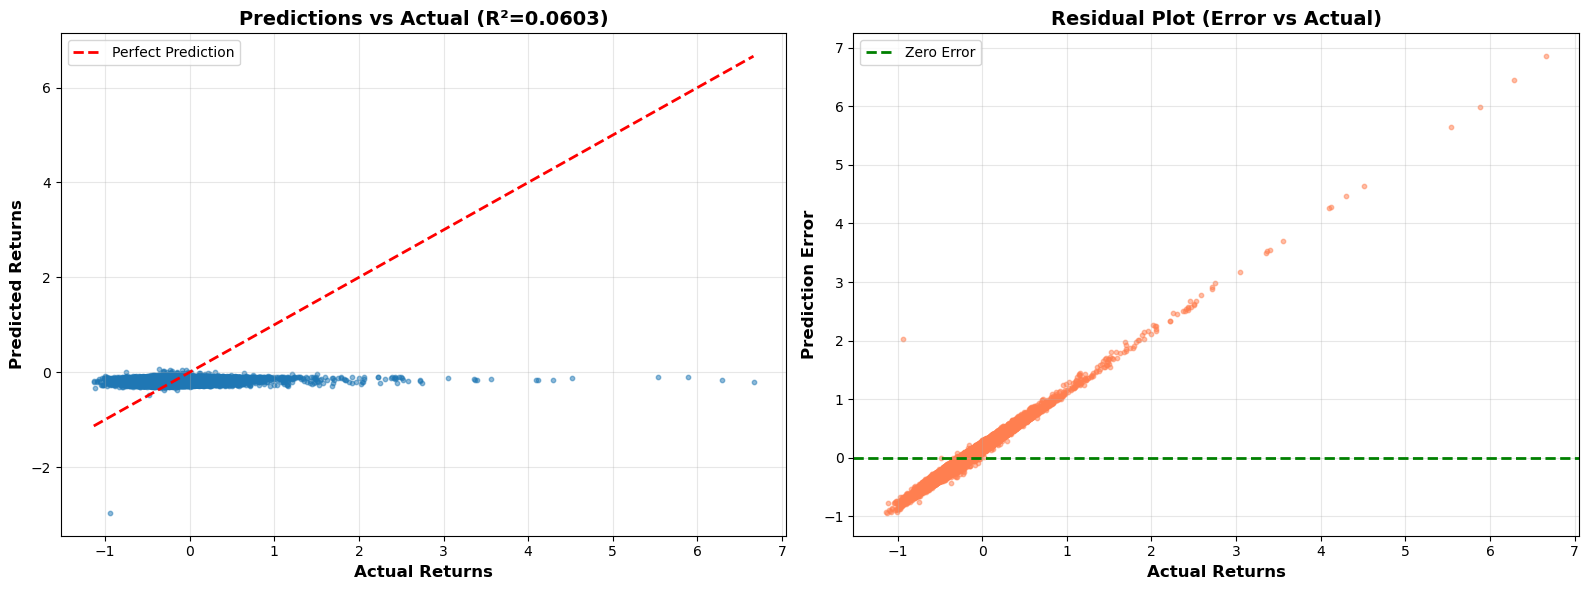

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Predictions vs Actual (with perfect prediction line)
axes[0].scatter(y_val_actual, val_pred, alpha=0.5, s=10)
axes[0].plot([y_val_actual.min(), y_val_actual.max()], 
             [y_val_actual.min(), y_val_actual.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Returns', fontsize=12, fontweight='bold')
axes[0].set_title(f'Predictions vs Actual (R²={r2:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# RIGHT: Residual Plot
errors = y_val_actual - val_pred
axes[1].scatter(y_val_actual, errors, alpha=0.5, s=10, color='coral')
axes[1].axhline(y=0, color='green', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Actual Returns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prediction Error', fontsize=12, fontweight='bold')
axes[1].set_title('Residual Plot (Error vs Actual)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Top-Left (Predictions vs Actual - Full Range):
- NNL model predicts a narrow range (~-0.2 to +0.4) while actual returns span -1 to +7
- Massive underprediction problem - the model is too conservative and fails to capture market movements
- R²=0.06 means the model explains only 6% of variance

Bottom-Right (Residual Plot):
- Errors increase linearly with actual returns - classic heteroscedasticity
- For large positive returns (>2), errors are massive (up to 7!)
- Pattern shows the model systematically misses big winners and losers


In [232]:
# Get test set predictions
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

best_model.eval()
with torch.no_grad():
    test_pred_scaled = best_model(X_test_t).numpy()

test_pred = scaler_y.inverse_transform(test_pred_scaled)
y_test_actual = y_test.reshape(-1, 1)

# Get actual next-month returns and dates for test period
test_returns = df_work.loc[test_mask, "ret_next"].values
test_dates = df_work.loc[test_mask, "date"].values
test_rf = df_work.loc[test_mask, "rf"].values if "rf" in df_work.columns else None

In [233]:
# create portfolios dataframe
df_test = pd.DataFrame({
    'date': test_dates,
    'y_actual': y_test_actual.flatten(),
    'y_pred': test_pred.flatten(),
    'ret_next': test_returns,  # Actual realized return
})


### Long-Short Portfolio Construction

**At each month $t$:**

#### Step 1: Get predictions for all stocks

For each stock $i$ in universe: $\hat{y}_{i,t} = \text{NN}(\mathbf{x}_{i,t})$

#### Step 2: Sort stocks by predicted returns

Rank stocks: $\hat{y}_{(1),t} \leq \hat{y}_{(2),t} \leq \ldots \leq \hat{y}_{(N_t),t}$

where $N_t$ = number of stocks available in month $t$

#### Step 3: Form quintiles

$$Q = \left\lfloor \frac{N_t}{4} \right\rfloor \text{ (quintile size)}$$

**Short Portfolio (Bottom 20%):**

$$\mathcal{S}_t = \{\text{stocks with ranks } 1, 2, \ldots, Q\}$$

**Long Portfolio (Top 20%):**

$$\mathcal{L}_t = \{\text{stocks with ranks } (N_t - Q + 1), \ldots, N_t\}$$

#### Step 4: Calculate portfolio returns

Equal-weighted within each quintile:

$$r_{\text{short},t} = \frac{1}{Q} \sum_{i \in \mathcal{S}_t} r_{i,t}$$

$$r_{\text{long},t} = \frac{1}{Q} \sum_{i \in \mathcal{L}_t} r_{i,t}$$

$$r_{\text{portfolio},t} = r_{\text{long},t} - r_{\text{short},t}$$

Where:
- $r_{i,t}$ = actual realized return of stock $i$ in month $t$
- $r_{\text{portfolio},t}$ = long-short portfolio return in month $t$

In [367]:
# Long-Short Portfolio function
def create_long_short_portfolio(group):
    group = group.sort_values('y_pred')
    n = len(group)
    n_quintile = max(1, n // 4)
    
    short_return = group.head(n_quintile)['ret_next'].mean()  # Bottom 25%
    long_return = group.tail(n_quintile)['ret_next'].mean()   # Top 25%
    
    return long_return - short_return

monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()
monthly_portfolio.columns = ['date', 'portfolio_return']


/var/folders/7t/6w33mppn51j3pkgbzwyh6ck40000gn/T/ipykernel_52026/1743065203.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_portfolio = df_test.groupby('date').apply(create_long_short_portfolio).reset_index()


In [73]:
# Get monthly S&P 500 returns (without dividends) and Risk-Free returns
sp500_monthly = df[df['date'] >= "2020-01-01"].groupby('date')['ret_x'].first().reset_index()
sp500_monthly.columns = ['date', 'sp500_return']
rf_monthly = df[df['date'] >= "2020-01-01"].groupby('date')['rf'].first().reset_index()
rf_monthly.columns = ['date', 'rf_return']

In [369]:
# Merge all returns
returns_df = monthly_portfolio.merge(sp500_monthly, on='date', how='left')
returns_df = returns_df.merge(rf_monthly, on='date', how='left')

# Handle any missing values
returns_df = returns_df.fillna(0)

returns_df.head(5)

,date,portfolio_return,sp500_return,rf_return
0,2020-01-01,-0.002990,0.000108,0.0013
1,2020-02-01,0.048157,-0.081872,0.0012
2,2020-03-01,-0.062327,-0.121997,0.0012
3,2020-04-01,0.000452,0.128890,0.0000
4,2020-05-01,0.049388,0.047818,0.0001


In [370]:
# Calculate cumulative returns
returns_df['cum_portfolio'] = (1 + returns_df['portfolio_return']).cumprod() - 1
returns_df['cum_sp500'] = (1 + returns_df['sp500_return']).cumprod() - 1
returns_df['cum_rf'] = (1 + returns_df['rf_return']).cumprod() - 1

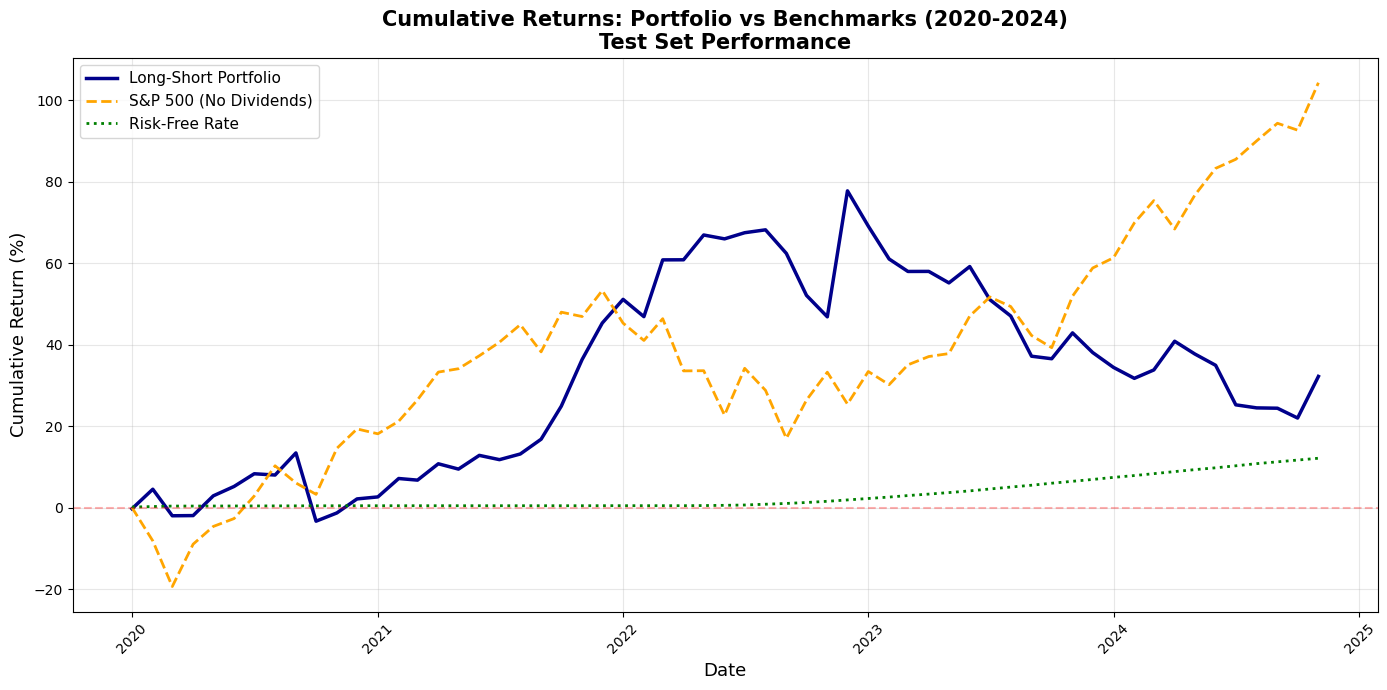

In [371]:
# Plot cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(returns_df['date'], returns_df['cum_portfolio'] * 100, 
         linewidth=2.5, label='Long-Short Portfolio', color='darkblue')
plt.plot(returns_df['date'], returns_df['cum_sp500'] * 100, 
         linewidth=2, label='S&P 500 (No Dividends)', color='orange', linestyle='--')
plt.plot(returns_df['date'], returns_df['cum_rf'] * 100, 
         linewidth=2, label='Risk-Free Rate', color='green', linestyle=':')

plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Cumulative Return (%)', fontsize=13)
plt.title('Cumulative Returns: Portfolio vs Benchmarks (2020-2024)\nTest Set Performance', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [372]:
def calculate_metrics(returns, rf_returns):
    """Calculate comprehensive performance metrics"""
    total_return = (1 + returns).prod() - 1
    monthly_avg = returns.mean()
    monthly_vol = returns.std()
    excess_returns = returns - rf_returns
    sharpe = np.sqrt(12) * (excess_returns.mean() / excess_returns.std()) if excess_returns.std() > 0 else 0
    
    return {
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{((1 + total_return)**(12/len(returns)) - 1)*100:.2f}%",
        'Annualized Sharpe': f"{sharpe:.4f}",
        'Monthly Avg Return': f"{monthly_avg*100:.4f}%",
        'Monthly Volatility': f"{monthly_vol*100:.4f}%"
    }

In [373]:
# Calculate for all assets
portfolio_metrics = calculate_metrics(returns_df['portfolio_return'], returns_df['rf_return'])
sp500_metrics = calculate_metrics(returns_df['sp500_return'], returns_df['rf_return'])
rf_metrics = calculate_metrics(returns_df['rf_return'], returns_df['rf_return'])


# Print comparison table
print("="*80)
print("COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)")
print("="*80)
print(f"\n{'Metric':<25} {'Portfolio':<20} {'S&P 500':<20} {'Risk-Free':<20}")
print("-"*80)
for key in portfolio_metrics.keys():
    port_val = portfolio_metrics.get(key, 'N/A')
    sp_val = sp500_metrics.get(key, 'N/A')
    rf_val = rf_metrics.get(key, 'N/A')
    print(f"{key:<25} {port_val:<20} {sp_val:<20} {rf_val:<20}")

COMPREHENSIVE PERFORMANCE COMPARISON (2020-2024)

Metric                    Portfolio            S&P 500              Risk-Free           
--------------------------------------------------------------------------------
Total Return              32.19%               104.27%              12.11%              
Annualized Return         5.84%                15.64%               2.35%               
Annualized Sharpe         0.2709               0.7627               0.0000              
Monthly Avg Return        0.6032%              1.3554%              0.1941%             
Monthly Volatility        5.1805%              5.2787%              0.1944%             


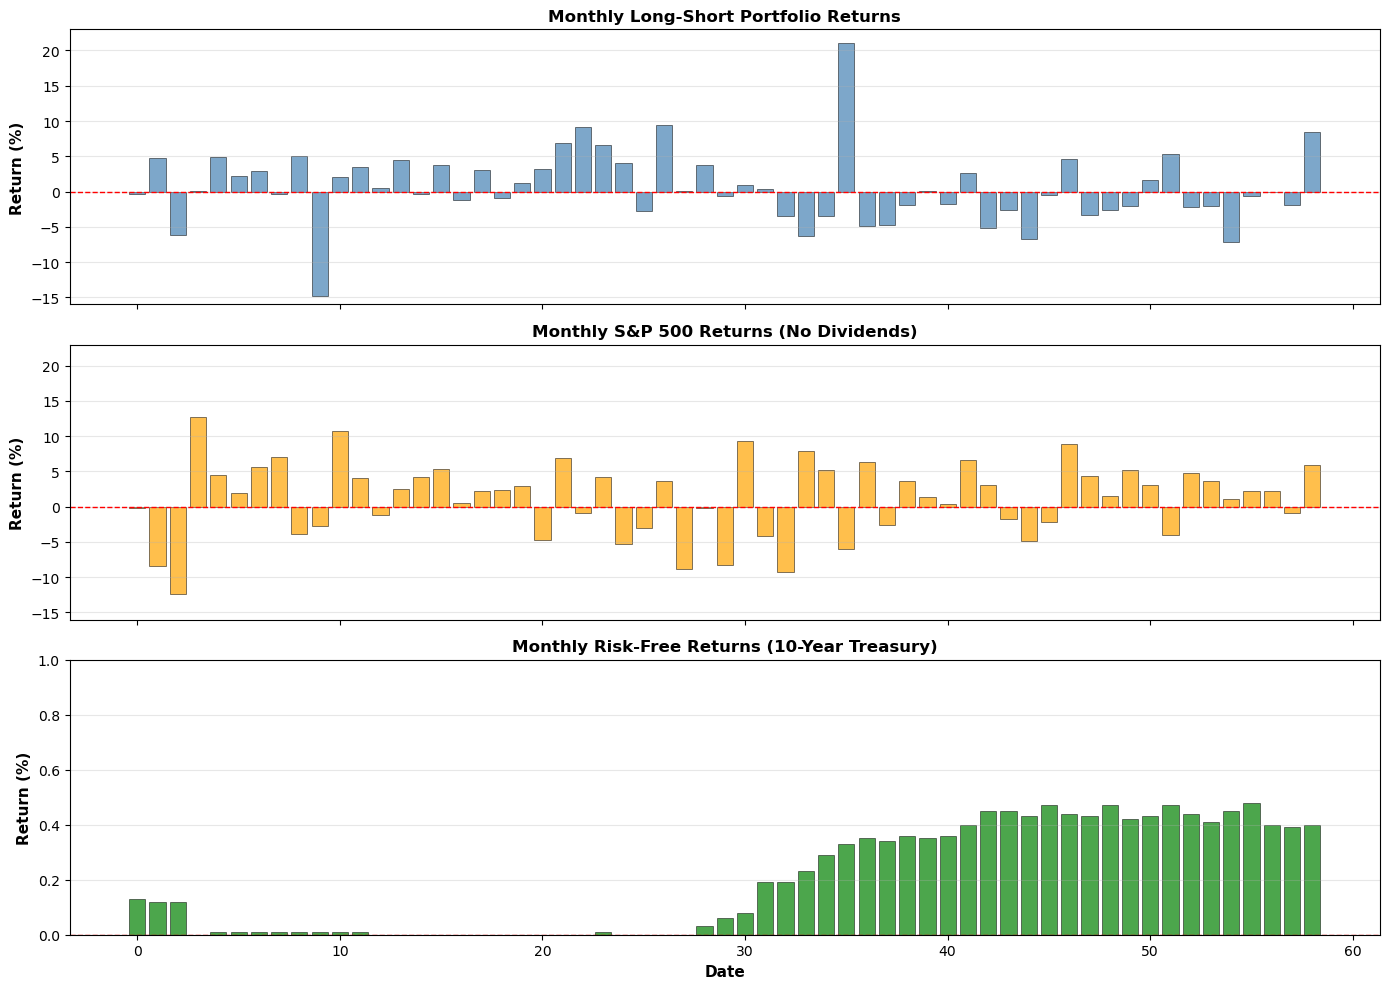

In [360]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the global y-axis range across all three series
all_returns = np.concatenate([
    returns_df['portfolio_return'].values,
    returns_df['sp500_return'].values, 
    returns_df['rf_return'].values  # Or new treasury returns
])

y_min = np.floor(all_returns.min() * 100) - 1  # Add padding
y_max = np.ceil(all_returns.max() * 100) + 1

# Create subplots with SHARED y-axis
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Portfolio Returns
axes[0].bar(returns_df.index, returns_df['portfolio_return'] * 100, 
            color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Monthly Long-Short Portfolio Returns', fontsize=12, fontweight='bold')
axes[0].set_ylim(y_min, y_max)  # FIXED RANGE
axes[0].grid(axis='y', alpha=0.3)

# S&P 500 Returns
axes[1].bar(returns_df.index, returns_df['sp500_return'] * 100,
            color='orange', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Monthly S&P 500 Returns (No Dividends)', fontsize=12, fontweight='bold')
axes[1].set_ylim(y_min, y_max)  # SAME RANGE
axes[1].grid(axis='y', alpha=0.3)

# Risk-Free Returns (Treasury)
axes[2].bar(returns_df.index, returns_df['rf_return'] * 100,
            color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[2].set_title('Monthly Risk-Free Returns (10-Year Treasury)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()